# Orchestrator-Worker Recipe Example (Layered Architecture)

---

This notebook demonstrates a **four-layer architecture** for LangGraph applications:

| Layer | Concern | Where it lives |
|---|---|---|
| **1 — Node functions** | Business logic only (state → partial update) | Plain Python functions |
| **2 — Node registration** | Per-node ops policy (retry, fallback, tags, metadata) | `wrap_node()` / `add_node()` factory |
| **3 — Graph invocation** | Run-level config (callbacks, tracing, run tags) | `make_run_config()` helper |
| **4 — Infrastructure** | Deployment concerns (timeouts, rate limits, scaling) | Outside the graph (documented) |

Even where concerns are **stubbed**, the architecture shows where they belong.

---
# Setup
---

In [1]:
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send
from langchain_core.runnables import RunnableLambda, Runnable, RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [2]:
from typing import TypedDict, Annotated, List, Callable, Any
from pydantic import BaseModel, Field
import operator
import os
from pathlib import Path
from pprint import pprint
from IPython.display import Image, display

In [3]:
from dotenv import load_dotenv

env_path = Path.home() / "Source" / "SECRETS" / ".env"
load_dotenv(env_path)

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

---
# Data Models & State Schemas
---

In [4]:
class Dish(BaseModel):
    name: str = Field(
        description="Name of the dish (for example, Spaghetti Bolognese, Chicken Curry)."
    )
    ingredients: List[str] = Field(
        description="List of ingredients needed for this dish, separated by commas."
    )
    location: str = Field(
        description="The cuisine or cultural origin of the dish (for example, Italian, Indian, Mexican)."
    )


class Dishes(BaseModel):
    sections: List[Dish] = Field(
        description="A list of grocery sections, one for each dish, with ingredients."
    )

In [5]:
class State(TypedDict):
    meals: str
    sections: List[Dish]
    completed_menu: Annotated[List[str], operator.add]
    final_meal_guide: str


class WorkerState(TypedDict):
    section: Dish
    completed_menu: Annotated[list, operator.add]

---
# Prompts & Pipelines
---

In [6]:
dish_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an assistant that generates a structured grocery list.\n\n"
        "The user wants to prepare the following meals: {meals}\n\n"
        "For each meal, return a section with:\n"
        "- the name of the dish\n"
        "- a comma-separated list of ingredients needed for that dish.\n"
        "- the cuisine or cultural origin of the food"
    )
])

chef_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a world-class chef from {location}.\n\n"
        "Please introduce yourself briefly and present a detailed walkthrough for preparing the dish: {name}.\n"
        "Your response should include:\n"
        "- Start with hello with your  name and culinary background\n"
        "- A clear list of preparation steps\n"
        "- A full explanation of the cooking process\n\n"
        "Use the following ingredients: {ingredients}."
    )
])

In [7]:
planner_pipe = dish_prompt | llm.with_structured_output(Dishes)
chef_pipe = chef_prompt | llm

---
# Layer 1 — Node Functions (Business Logic)

Each node is a **plain Python function**: `state in → partial state update out`.

Rules for this layer:
- No retries, timeouts, or logging policy inside the function.
- No awareness of "which graph I'm in".
- Testable with a plain dict input and a plain dict assertion.

---

In [8]:
def orchestrator(state: State) -> dict:
    """Orchestrator that generates a structured dish list from the given meals."""
    dish_descriptions = planner_pipe.invoke({"meals": state["meals"]})
    return {"sections": dish_descriptions.sections}

In [9]:
def chef_worker(state: WorkerState) -> dict:
    """Worker node that generates the cooking instructions for one meal section."""
    meal_plan = chef_pipe.invoke({
        "name": state["section"].name,
        "location": state["section"].location,
        "ingredients": state["section"].ingredients
    })
    return {"completed_menu": [meal_plan.content]}

In [10]:
def synthesizer(state: State) -> dict:
    """Synthesize full report from sections."""
    completed_sections = state["completed_menu"]
    completed_menu = "\n\n---\n\n".join(completed_sections)
    return {"final_meal_guide": completed_menu}

In [11]:
def assign_workers(state: State):
    """Assign a worker to each section in the plan."""
    return [
        Send(
            "chef_worker",
            {"section": s, "completed_menu": []}
        )
        for s in state["sections"]
    ]

---
# Layer 2 — Node Registration (Per-Node Ops Policy)

This layer adapts plain functions into `Runnable`s and attaches **per-node operational policy**.

Concerns that belong here:
- **Tags / metadata** — for tracing and filtering
- **Retries** — for transient errors (429, 5xx)
- **Fallbacks** — backup runnable for high-value nodes
- **Per-node timeouts** — if supported by runtime

All policy is centralized in `wrap_node()` so it is **consistent and auditable**.

---

In [12]:
def wrap_node(
    fn: Callable[..., dict],
    *,
    node_id: str,
    tag: bool = True,
    metadata: bool = True,
    retry: bool = False,
    fallback: Runnable | None = None,
) -> Runnable:
    """Adapt a plain node function into a Runnable with operational policy.

    This is the single place where per-node ops concerns are attached.
    """
    r: Runnable = RunnableLambda(fn)

    # --- Tags & metadata (observability) ---
    cfg: dict[str, Any] = {}
    if tag:
        cfg["tags"] = [f"node:{node_id}"]
    if metadata:
        cfg["metadata"] = {"node_id": node_id}
    if cfg:
        r = r.with_config(**cfg)

    # --- Retry (transient errors only) ---
    # STUB: disabled by default; enable per node for LLM-heavy nodes
    if retry:
        r = r.with_retry(stop_after_attempt=3)

    # --- Fallback ---
    # STUB: pass a backup Runnable for critical nodes
    if fallback is not None:
        r = r.with_fallbacks([fallback])

    return r

In [13]:
def add_node(
    builder: StateGraph,
    node_id: str,
    fn: Callable[..., dict],
    *,
    tag: bool = True,
    metadata: bool = True,
    retry: bool = False,
    fallback: Runnable | None = None,
) -> None:
    """Register a node on the graph builder.

    The node_id is specified once and used for both the graph key
    and the runnable's tags/metadata (no duplication).
    """
    builder.add_node(
        node_id,
        wrap_node(
            fn,
            node_id=node_id,
            tag=tag,
            metadata=metadata,
            retry=retry,
            fallback=fallback,
        ),
    )

---
# Layer 3 — Graph Invocation (Run-Level Config)

This layer provides config that applies to the **entire run**, not individual nodes.

Concerns that belong here:
- **Callbacks / tracing handlers** — LangSmith, OpenTelemetry, custom loggers
- **Run-level tags** — environment, user ID, request ID, graph version
- **Run-level metadata** — correlation IDs, A/B test variants
- **Recursion limits** — how deep the graph can recurse

All run config is centralized in `make_run_config()` so you can toggle
tracing/observability without touching node code or graph wiring.

---

In [14]:
def make_run_config(
    *,
    env: str = "dev",
    graph_name: str = "orchestrator_worker",
    graph_version: str = "0.1.0",
    user_id: str | None = None,
    request_id: str | None = None,
    callbacks: list | None = None,
) -> RunnableConfig:
    """Build a run-level config dict for graph.invoke().

    STUB: today this returns tags and metadata only.
    In production, wire in LangSmith / OpenTelemetry callbacks here.
    """
    tags = [f"env:{env}", f"graph:{graph_name}", f"version:{graph_version}"]

    meta: dict[str, Any] = {
        "env": env,
        "graph_name": graph_name,
        "graph_version": graph_version,
    }
    if user_id:
        meta["user_id"] = user_id
    if request_id:
        meta["request_id"] = request_id

    config: RunnableConfig = {
        "tags": tags,
        "metadata": meta,
    }

    # STUB: attach callbacks when ready
    # e.g. from langsmith import Client; callbacks = [Client().tracing_callback()]
    if callbacks:
        config["callbacks"] = callbacks

    return config

---
# Graph Assembly & Execution

This section wires the graph using the Layer 2 helpers,
then invokes it using the Layer 3 run config.

---

In [15]:
# --- Build the graph ---
builder = StateGraph(State)

# Layer 2: register nodes with per-node ops policy
add_node(builder, "orchestrator", orchestrator, retry=True)
add_node(builder, "chef_worker",  chef_worker,  retry=True)
add_node(builder, "synthesizer",  synthesizer)

In [16]:
# --- Wire edges ---
builder.add_edge(START, "orchestrator")

builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["chef_worker"]
)

builder.add_edge("chef_worker", "synthesizer")
builder.add_edge("synthesizer", END)

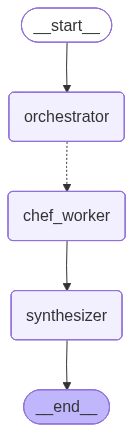

In [17]:
# --- Compile ---
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
# --- Invoke with Layer 3 run config ---
run_config = make_run_config(env="dev", user_id="chris")

result = graph.invoke(
    {"meals": "Steak and eggs, tacos, and chili"},
    config=run_config,
)

pprint(result["final_meal_guide"][:2000])

('Hello! My name is Chef Alex, and I have over 15 years of experience in the '
 "culinary arts, specializing in classic American cuisine. Today, I'm excited "
 'to share with you a delicious and hearty dish that is perfect for breakfast '
 'or brunch: Steak and Eggs. This dish combines the rich flavors of a '
 'perfectly cooked steak with the simplicity of eggs, creating a satisfying '
 "meal that's sure to impress.\n"
 '\n'
 '### Ingredients:\n'
 '- 1 steak (your choice of cut, such as ribeye, sirloin, or filet mignon)\n'
 '- 2 large eggs\n'
 '- Salt (to taste)\n'
 '- Pepper (to taste)\n'
 '- 2 tablespoons of butter\n'
 '\n'
 '### Preparation Steps:\n'
 '1. **Choose and Prepare the Steak**: Select your preferred cut of steak and '
 'allow it to come to room temperature (about 30 minutes before cooking). Pat '
 'it dry with paper towels and season both sides generously with salt and '
 'pepper.\n'
 '\n'
 '2. **Prepare the Cooking Surface**: Preheat a heavy skillet (preferably cast '
 '

---
# Layer 4 — Infrastructure (Outside the Graph)

These concerns live **outside** the LangGraph code, at the deployment / platform level.

Nothing to implement here in a notebook, but documenting where they belong:

| Concern | Where it lives | Example |
|---|---|---|
| **Request-level timeouts** | HTTP server, task queue, k8s | FastAPI `timeout`, Celery `time_limit` |
| **Rate limiting** | API gateway or LLM client config | `ChatOpenAI(max_retries=..., timeout=...)` |
| **Circuit breakers** | Service mesh or middleware | Stop calling a provider that is down |
| **Secrets / credentials** | Env vars, vault, k8s secrets | `.env`, AWS Secrets Manager |
| **Scaling / concurrency** | Worker pools, k8s HPA | Celery workers, Ray, k8s replicas |
| **Persistence / checkpointing** | LangGraph checkpointer config | `SqliteSaver`, `PostgresSaver` |

### When to promote concerns from Layer 2 → Layer 4

- **Timeouts**: start as per-node stubs in Layer 2; in production, enforce at the
  infrastructure level (HTTP gateway, task queue) for hard guarantees.
- **Rate limiting**: start with LLM client settings; in production, add API gateway limits.
- **Retries**: keep transient-error retries in Layer 2; add circuit breakers in Layer 4
  for systemic failures.

---